# **Engineering Probability and Statistics**

## **Computer Assignment 6**

**School of Electrical and Computer Engineering**  
**College of Engineering, University of Tehran**

**Instructors:** Dr. Bahrak, Dr. Vahhabi  
**Designers:** [Yasaman Amou Jafary](https://github.com/yasamanamoujafary), [Parsa Bukani](https://github.com/parsabukani)

**Topic:** Central Limit Theorem and Parameter Estimation

## **Table of Contents**

* **[Central Limit Theorem in Practice](#central-limit-theorem-in-practice)**

  * [Section 1: Skewed Daily Watch-Time Dataset](#section-1-skewed-daily-watch-time-dataset)

    * [Exploring the Dataset](#exploring-the-dataset)
    * [Section 1.1: Sample Means for Different Sample Sizes](#section-11-sample-means-for-different-sample-sizes)
    * [Section 1.2: Probability That the Sample Mean Lies in the Interval](#section-12-probability-that-the-sample-mean-lies-in-the-interval)
  * [Section 2: CLT for Simple Known Distributions](#section-2-clt-for-simple-known-distributions)

* **[Benford’s Law in Real-World Data](#benfords-law-in-real-world-data)**

  * [Section 1: Benford’s Law and the CLT Connection](#section-1-benfords-law-and-the-clt-connection)
  * [Section 2: Implementing Benford’s Law in R](#section-2-implementing-benfords-law-in-r)
  * [Section 3: Loading the Dataset and Constructing GDP](#section-3-loading-the-dataset-and-constructing-gdp)
  * [Section 4: Verifying Benford’s Law Using GDP](#section-4-verifying-benfords-law-using-gdp)

* **[Estimating MKG Café Busyness - Parameter Estimation](#mkg-parameter)**

  * [Setup](#setup)
  * [Section 1: One Observed Sample](#section-1-one-observed-sample)
  * [Section 2: Maximum Likelihood (ML) as a Curve](#section-2-maximum-likelihood-ml-as-a-curve)
  * [Section 3: ML Estimate from the Sample](#section-3-ml-estimate-from-the-sample)
  * [Section 4: What Happens When We Observe More Hours?](#section-4-what-happens-when-we-observe-more-hours)
  * [Section 5: True vs Estimated Distribution](#section-5-true-vs-estimated-distribution)

## **Central Limit Theorem in Practice**

### Section 1: SKEWED DAILY WATCH-TIME DATASET

#### Exploring the Dataset

In [3]:
set.seed(123)

n_users <- 5000

# Proportions of each user type
props <- c(light = 0.5, medium = 0.35, heavy = 0.15)

n_light  <- round(n_users * props["light"])
n_medium <- round(n_users * props["medium"])
n_heavy  <- n_users - n_light - n_medium

# Light users: mean 10, sd 4
light_users  <- rnorm(n_light,  mean = 10, sd = 4)

# Medium users: mean 40, sd 8
medium_users <- rnorm(n_medium, mean = 40, sd = 8)

# Heavy users: mean 90, sd 15
heavy_users  <- rnorm(n_heavy,  mean = 90, sd = 15)

watch_time <- c(light_users, medium_users, heavy_users)

# Truncate at 0 and 300 minutes to keep it realistic
watch_time[watch_time < 0]   <- 0
watch_time[watch_time > 300] <- 300

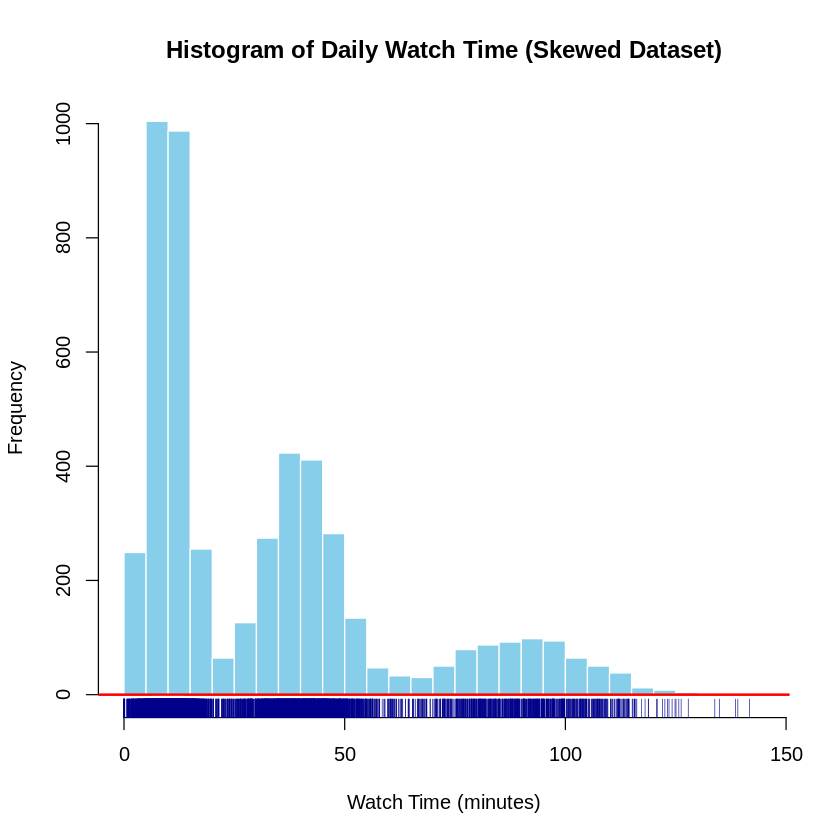

In [4]:
# Histogram of the original watch_time data
hist(
  watch_time,
  breaks = 50,
  col = "skyblue",
  border = "white",
  main = "Histogram of Daily Watch Time (Skewed Dataset)",
  xlab = "Watch Time (minutes)",
  ylab = "Frequency"
)

# Add a rug plot for individual observations
rug(watch_time, col = "darkblue")

# Overlay density curve for smoother visualization
lines(density(watch_time), col = "red", lwd = 2)

#### Section 1.1: Sample Means for Different Sample Sizes


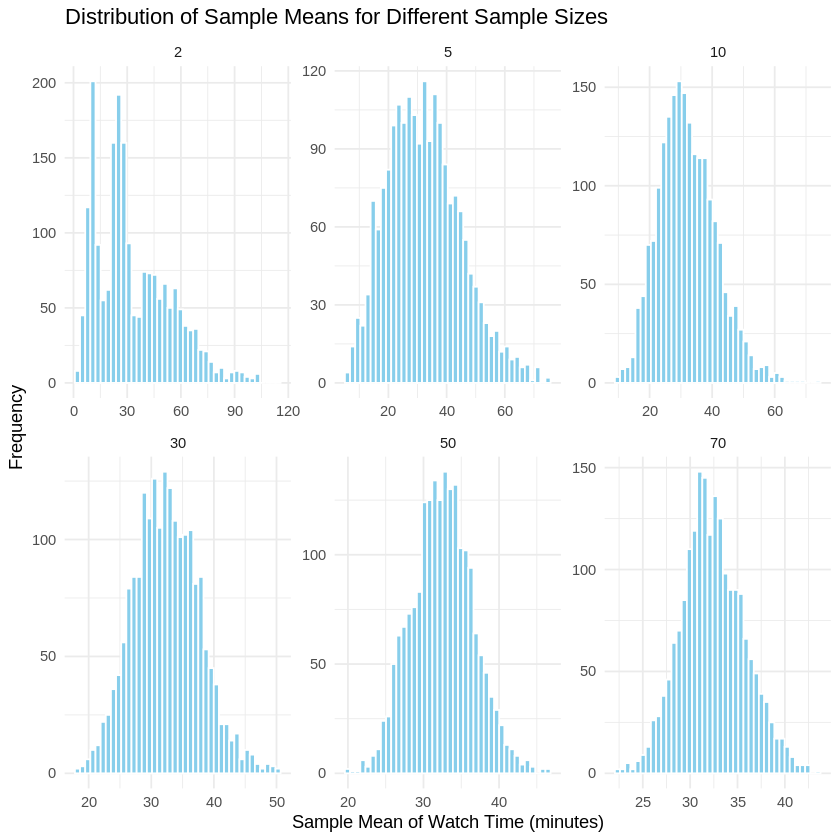

In [6]:
library(ggplot2)

# Define sample sizes and repetitions
sample_sizes <- c(2, 5, 10, 30, 50, 70)
B <- 2000

# Generate sample means for each sample size
sample_means <- lapply(sample_sizes, function(n) {
  replicate(B, mean(sample(watch_time, n, replace = TRUE)))
})

# Put results into a tidy data frame
df_means <- data.frame(
  sample_mean = unlist(sample_means),
  n = factor(rep(sample_sizes, each = B))
)

# Plot histograms of sample means for each n
ggplot(df_means, aes(x = sample_mean)) +
  geom_histogram(bins = 40, fill = "skyblue", color = "white") +
  facet_wrap(~ n, scales = "free") +
  labs(
    title = "Distribution of Sample Means for Different Sample Sizes",
    x = "Sample Mean of Watch Time (minutes)",
    y = "Frequency"
  ) +
  theme_minimal()


#### Section 1.2: Probability That the Sample Mean Lies in the Interval


Estimated mu (watch_time): 32.45821 
Estimated sigma (watch_time): 28.7749 
Interval [a, b]: 22.86658 - 42.04984 
Theoretical probability: 0.9544997 
Simulated probability: 0.9587 


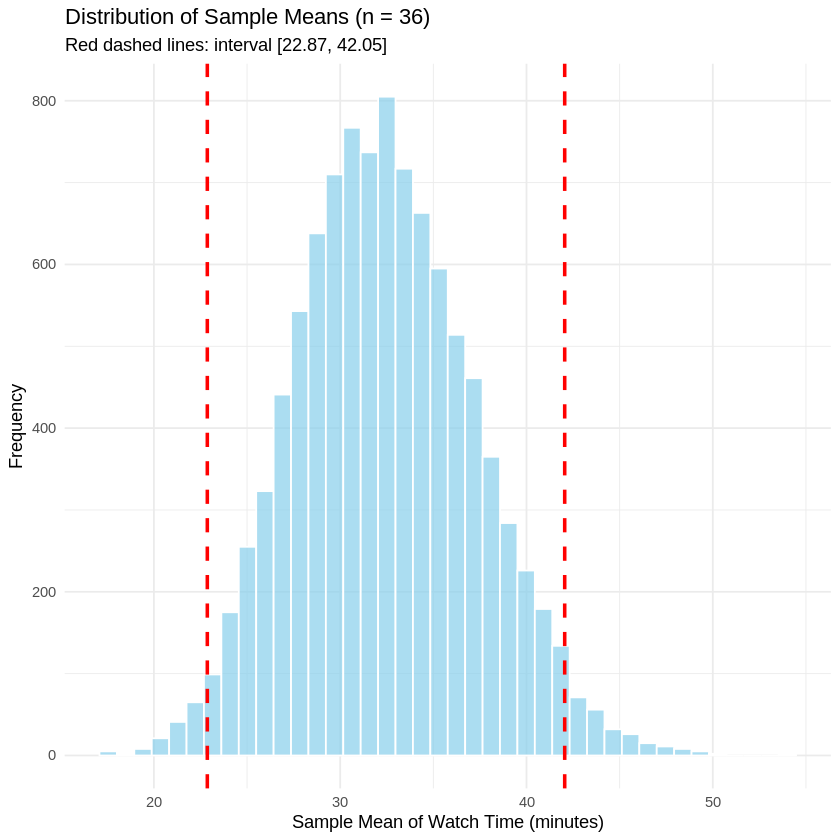

In [8]:
set.seed(789)

# Estimate MU and SIGMA from WATCH_TIME
mu_hat    <- mean(watch_time)
sigma_hat <- sd(watch_time)

cat("Estimated mu (watch_time):", mu_hat,    "\n")
cat("Estimated sigma (watch_time):", sigma_hat, "\n")

# Choose a sample size
n <- 36

# --- Step 1: Compute standard error and CLT band ---
sigma_bar <- sigma_hat / sqrt(n)
a <- mu_hat - 2 * sigma_bar
b <- mu_hat + 2 * sigma_bar

cat("Interval [a, b]:", a, "-", b, "\n")

# --- Step 2: Theoretical probability using CLT approximation ---
# X_bar ~ Normal(mu_hat, sigma_hat^2 / n)
p_theoretical <- pnorm(b, mean = mu_hat, sd = sigma_bar) -
                 pnorm(a, mean = mu_hat, sd = sigma_bar)

cat("Theoretical probability:", p_theoretical, "\n")

# --- Step 3: Practical probability via simulation ---
B <- 10000
sample_means <- replicate(B, mean(sample(watch_time, n, replace = TRUE)))
p_simulated <- mean(sample_means > a & sample_means < b)

cat("Simulated probability:", p_simulated, "\n")

# --- Step 4: Visualization ---
library(ggplot2)

ggplot(data.frame(sample_means), aes(x = sample_means)) +
  geom_histogram(bins = 40, fill = "skyblue", color = "white", alpha = 0.7) +
  geom_vline(xintercept = c(a, b), color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Distribution of Sample Means (n = 36)",
    subtitle = paste0("Red dashed lines: interval [", round(a,2), ", ", round(b,2), "]"),
    x = "Sample Mean of Watch Time (minutes)",
    y = "Frequency"
  ) +
  theme_minimal()



### Section 2: CLT for Simple Known Distributions

In Part 1, you saw that sample means from a messy, skewed “watch time” dataset became more and more bell‑shaped as the sample size increased. But maybe this was just a special case

In this part, you will:

Work with three simple, well‑known distributions:

- Uniform(0, 1)

- Exponential(rate = 1)

- Bernoulli(p = 0.3)

For each distribution:

- Generate raw data and plot its histogram to see the original shape.

- Generate many sample means for n = 5, 10, 30.

- Compare the histogram of the sample means with the theoretical normal curve predicted by the CLT:
mean = μ, variance = σ² / n.

In [9]:
set.seed(456)

B <- 2000
n_values <- c(5, 10, 30, 50, 70)

# Distribution generators
r_unif <- function(n) runif(n, min = 0, max = 1)
r_exp  <- function(n) rexp(n, rate = 1)
p_bern <- 0.3
r_bern <- function(n) rbinom(n, size = 1, prob = p_bern)

dist_list <- list(
  uniform     = r_unif,
  exponential = r_exp,
  bernoulli   = r_bern
)

# Theoretical mean (mu) and variance (sigma^2) for each distribution
dist_params <- list(
  uniform     = list(mu = 0.5, sigma2 = 1/12),
  exponential = list(mu = 1,   sigma2 = 1),
  bernoulli   = list(mu = p_bern,
                     sigma2 = p_bern * (1 - p_bern))
)

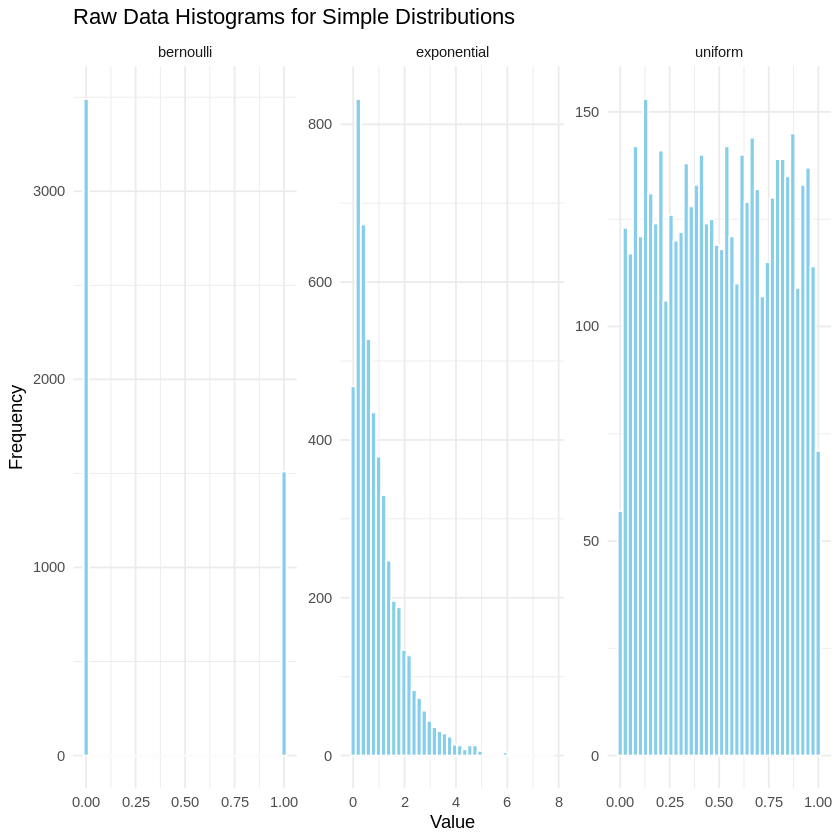

In [10]:
set.seed(456)

library(ggplot2)

# Number of raw samples for visualization
N_raw <- 5000

# Generate raw data for each distribution
raw_data <- list(
  uniform     = r_unif(N_raw),
  exponential = r_exp(N_raw),
  bernoulli   = r_bern(N_raw)
)

# Convert to tidy data frame
df_raw <- data.frame(
  value = unlist(raw_data),
  dist  = factor(rep(names(raw_data), each = N_raw))
)

# Plot histograms for each distribution
ggplot(df_raw, aes(x = value)) +
  geom_histogram(bins = 40, fill = "skyblue", color = "white") +
  facet_wrap(~ dist, scales = "free") +
  labs(
    title = "Raw Data Histograms for Simple Distributions",
    x = "Value",
    y = "Frequency"
  ) +
  theme_minimal()


## **Benford’s Law in Real-World Data**

### Section 1: Benford’s Law and the CLT connection


In this section you will:
1. Derive the Benford probability for the first digit:
$$
P(D=d)=\log_{10}\left(1+\frac{1}{d}\right),\quad d=1,\dots,9.
$$
2. Explain (conceptually) how the Central Limit Theorem (CLT) makes Benford’s law appear in real-world data.

TODO:

Example:

P(D=1)=log10(2)≈0.301 → about 30% of numbers start with 1.

𝑃(𝐷=9)=log10(1+1/9)≈0.046 → only 4.6% start with 9.

Conceptual CLT Connection
Many real-world datasets (populations, financial figures, natural phenomena) are multiplicative in nature (growth rates, scaling, compounding).

When you take logarithms of such data, the distribution often spreads across several orders of magnitude.

The Central Limit Theorem (CLT) explains why averages of many independent random processes tend toward normality.

In the log scale, this “normal-like” spread across magnitudes makes the leading digits follow Benford’s distribution.

In short: CLT ensures stability of averages, and when combined with multiplicative growth across scales, it naturally produces Benford’s Law in real-world data.


### Section 2: Implementing Benford’s Law in R

In this section, you will implement Benford’s Law in R.
First, you will write a function that returns the theoretical Benford probability for a given leading digit.  
Then, you will use this function to compute the probabilities for all digits and visualize the Benford distribution.

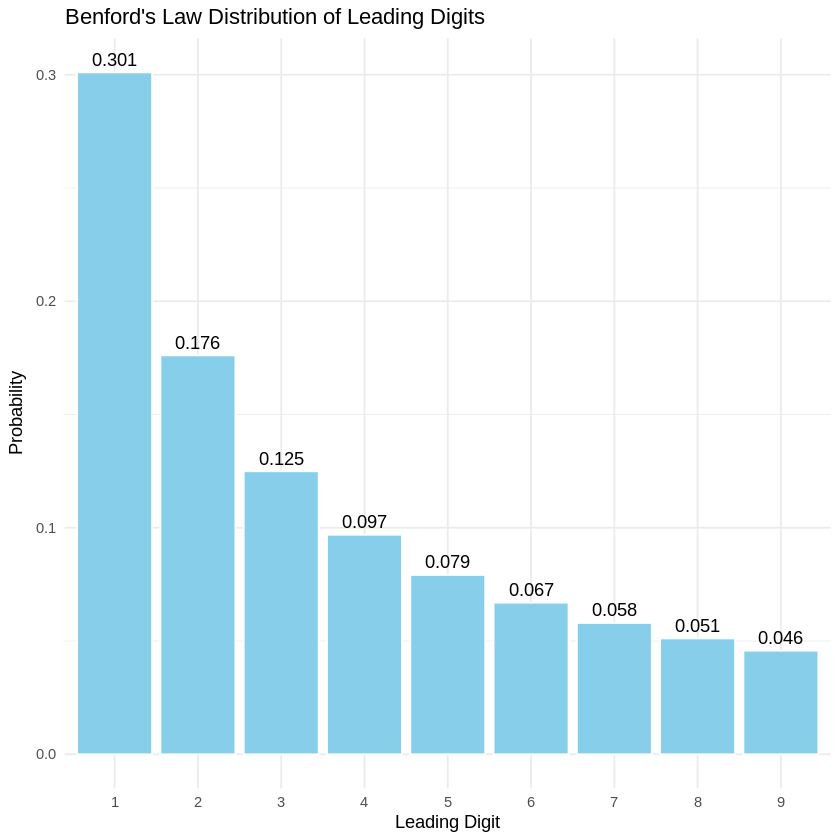

In [11]:
# Define Benford probability function
benford_prob <- function(n) {
  if (n < 1 || n > 9) {
    stop("n must be between 1 and 9")
  }
  log10(1 + 1/n)
}

# Digits 1 through 9
digits <- 1:9

# Compute probabilities
probs <- sapply(digits, benford_prob)

# Plot Benford distribution
library(ggplot2)

df_benford <- data.frame(
  digit = digits,
  probability = probs
)

ggplot(df_benford, aes(x = factor(digit), y = probability)) +
  geom_bar(stat = "identity", fill = "skyblue", color = "white") +
  geom_text(aes(label = round(probability, 3)), vjust = -0.5) +
  labs(
    title = "Benford's Law Distribution of Leading Digits",
    x = "Leading Digit",
    y = "Probability"
  ) +
  theme_minimal()


### Section 3: Loading the Dataset and Constructing GDP

In this section, you will load a real-world dataset and construct a new variable using a meaningful economic relationship.
The dataset contains population and GDP per capita values for different countries and years. Using these variables, you will compute the total Gross Domestic Product (GDP) as:
$$
\text{GDP} = \text{population} \times \text{GDP per capita}.
$$
This constructed variable will later be used to study the distribution of leading digits and compare it with Benford’s Law. **Why can this be an appropriate variable to verify the Benford's law?**

TODO:

GDP is an appropriate variable to verify Benford’s Law because it spans several orders of magnitude across countries and years, arises from natural multiplicative processes (population × GDP per capita), and is not artificially bounded. This diversity and scale make the distribution of leading digits in GDP values likely to follow Benford’s Law, similar to how the CLT explains convergence in averages.


In [12]:
# install the package for the first time only (uncomment the following code):
install.packages("gapminder")

library(gapminder)
data <- gapminder

# Create a new column GDP
data$GDP <- data$pop * data$gdpPercap

# Display the first few rows
head(data)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



country,continent,year,lifeExp,pop,gdpPercap,GDP
<fct>,<fct>,<int>,<dbl>,<int>,<dbl>,<dbl>
Afghanistan,Asia,1952,28.801,8425333,779.4453,6567086330
Afghanistan,Asia,1957,30.332,9240934,820.8530,7585448670
Afghanistan,Asia,1962,31.997,10267083,853.1007,8758855797
Afghanistan,Asia,1967,34.020,11537966,836.1971,9648014150
Afghanistan,Asia,1972,36.088,13079460,739.9811,9678553274
Afghanistan,Asia,1977,38.438,14880372,786.1134,11697659231


### Section 4: Verifying Benford’s Law Using GDP

In this section, you will empirically verify Benford’s Law using the GDP variable constructed in the previous section.
You will extract the leading digit of GDP values, compute the empirical distribution of leading digits, and **compare** it with the theoretical Benford distribution.

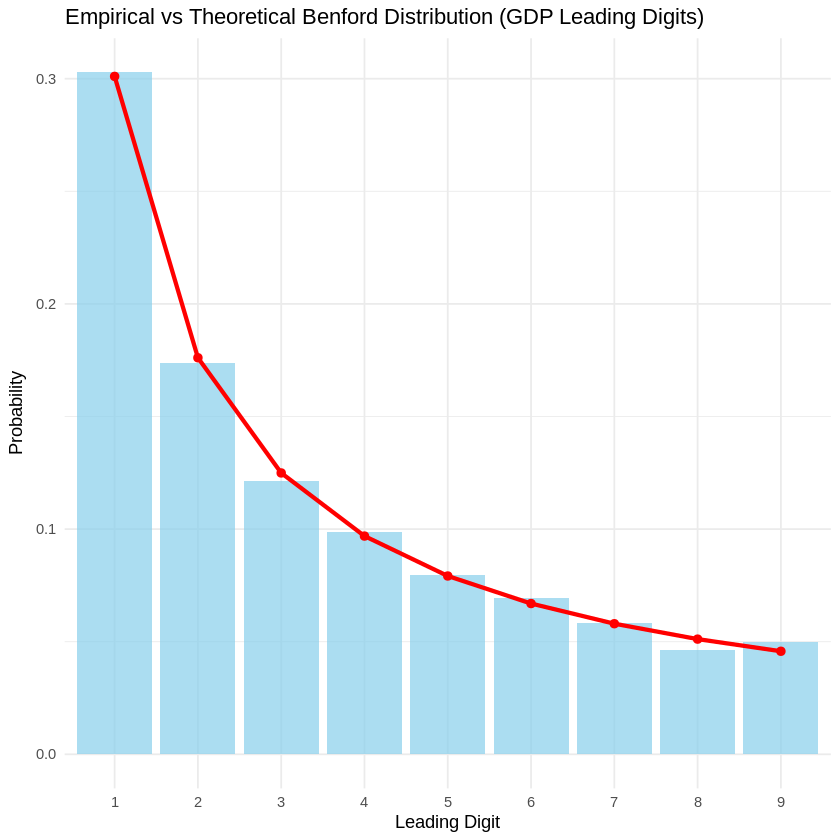

In [13]:
# Function to extract leading digit
leading_digit <- function(x) {
  if (is.na(x) || x <= 0) return(NA)   # remove non-positive or NA values
  digits <- unlist(strsplit(as.character(x), "")) # split into characters
  digits <- digits[digits != "0" & digits != "."] # remove zeros and decimal points
  as.numeric(digits[1]) # return the first non-zero digit
}

# Extract leading digits from GDP
gdp_digits <- sapply(data$GDP, leading_digit)
gdp_digits <- gdp_digits[!is.na(gdp_digits)]  # remove NA values

# Compute empirical distribution (relative frequencies)
empirical_freq <- table(gdp_digits) / length(gdp_digits)

# Theoretical Benford probabilities
benford_prob <- function(n) log10(1 + 1/n)
digits <- 1:9
theoretical_probs <- sapply(digits, benford_prob)

# Create tidy data frame for plotting
df_compare <- data.frame(
  digit = digits,
  empirical = as.numeric(empirical_freq[as.character(digits)]),
  theoretical = theoretical_probs
)

# Plot empirical vs theoretical distributions
library(ggplot2)

ggplot(df_compare, aes(x = factor(digit))) +
  geom_bar(aes(y = empirical), stat = "identity", fill = "skyblue", alpha = 0.7) +
  geom_line(aes(y = theoretical, group = 1), color = "red", size = 1.2) +
  geom_point(aes(y = theoretical), color = "red", size = 2) +
  labs(
    title = "Empirical vs Theoretical Benford Distribution (GDP Leading Digits)",
    x = "Leading Digit",
    y = "Probability"
  ) +
  theme_minimal()

<a id="mkg-parameter"></a>
## **Estimating MKG Café Busyness - Parameter Estimation**

### Setup

In [2]:
set.seed(7)

lambda_true <- 6  # hidden truth for simulation (customers/hour)

### Section 1: One observed sample

In [3]:
# Generate one 24-hour sample of hourly counts
x_obs <- rpois(24, lambda = lambda_true)

# Report the sample mean
sample_mean <- mean(x_obs)

cat("Observed hourly counts:", x_obs, "\n")
cat("Sample mean of observed counts:", sample_mean, "\n")


Observed hourly counts: 4 6 4 4 8 3 6 3 6 1 12 5 7 5 14 9 12 3 7 6 11 5 7 4 
Sample mean of observed counts: 6.333333 


### Section 2: Maximum Likelihood (ML) as a curve

Instead of formulas, we’ll try many λ values and compute how plausible the observed data looks under each λ. The best λ is at the peak (maximum likelihood).

ML estimate of lambda: 6.3 
Sample mean: 6.333333 


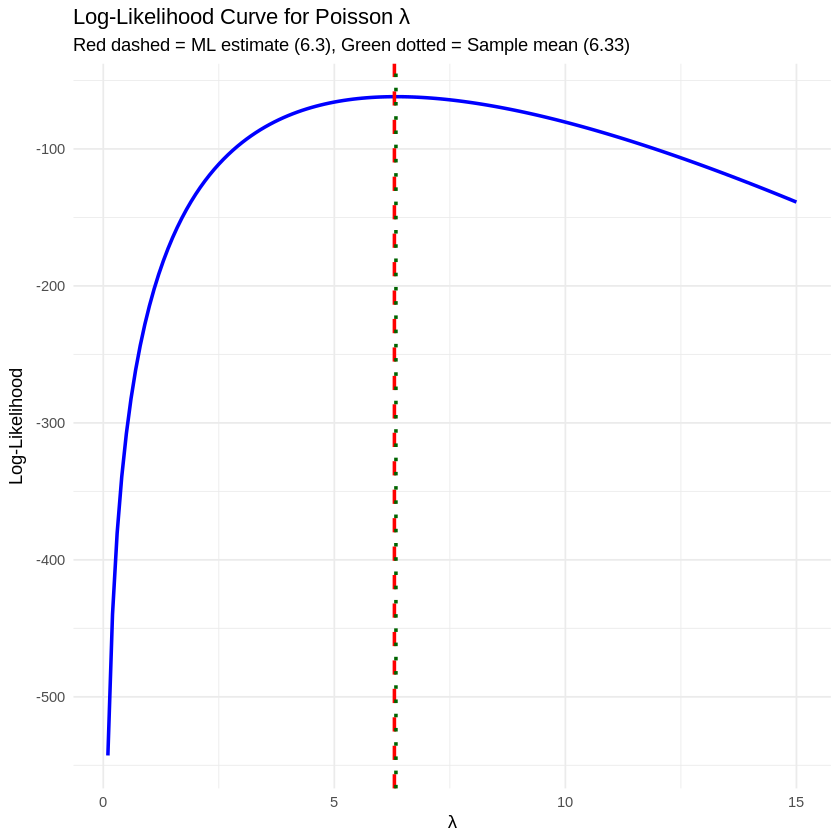

In [5]:
# 1) Try λ values from 0.1 to 15
lambda_vals <- seq(0.1, 15, by = 0.1)

# Compute log-likelihood for each λ
loglik <- sapply(lambda_vals, function(lam) {
  sum(dpois(x_obs, lambda = lam, log = TRUE))
})

# 2) Find the ML estimate (λ at maximum log-likelihood)
lambda_ml <- lambda_vals[which.max(loglik)]

cat("ML estimate of lambda:", lambda_ml, "\n")
cat("Sample mean:", sample_mean, "\n")

# 3) Plot log-likelihood curve and mark ML estimate + sample mean
library(ggplot2)

df_ll <- data.frame(lambda = lambda_vals, loglik = loglik)

ggplot(df_ll, aes(x = lambda, y = loglik)) +
  geom_line(color = "blue", linewidth = 1) +
  geom_vline(xintercept = lambda_ml, color = "red", linetype = "dashed", linewidth = 1) +
  geom_vline(xintercept = sample_mean, color = "darkgreen", linetype = "dotted", linewidth = 1) +
  labs(
    title = "Log-Likelihood Curve for Poisson λ",
    subtitle = paste0("Red dashed = ML estimate (", round(lambda_ml,2),
                      "), Green dotted = Sample mean (", round(sample_mean,2), ")"),
    x = expression(lambda),
    y = "Log-Likelihood"
  ) +
  theme_minimal()


### Section 3: ML estimate from the sample

For Poisson, the ML estimate equals the sample mean (your curve should peak right there).

In [6]:
# ML estimate of lambda (equals the sample mean)
lambda_ml <- mean(x_obs)

cat("ML estimate of λ (average events per hour):", lambda_ml, "\n")

ML estimate of λ (average events per hour): 6.333333 


### Section 4: What happens when we observe more hours?

Now we simulate repeated data collection. For each observation length, we repeat B = 1000 times to see the distribution of the estimate.

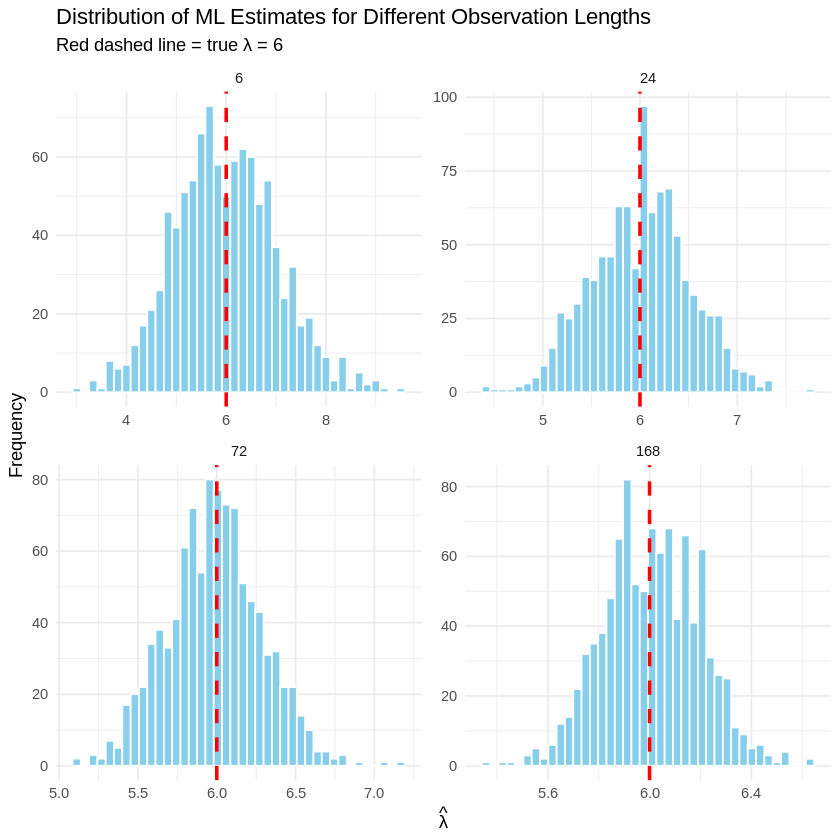

In [8]:
# TODO:
# 1) Pick several observation lengths (from a few hours up to many days).
# 2) For each length, repeat the experiment 1000 times: generate hourly counts and compute one λ estimate each time.
# 3) Store all estimates so you can compare how “spread out” the estimates are for short vs long observation periods.
set.seed(7)

lambda_true <- 6
B <- 1000

# 1) Pick several observation lengths (hours)
obs_lengths <- c(6, 24, 72, 168)  # 6 hours, 1 day, 3 days, 1 week

# 2) For each length, repeat experiment B times
estimates <- lapply(obs_lengths, function(n_hours) {
  replicate(B, mean(rpois(n_hours, lambda = lambda_true)))
})

# 3) Store all estimates in a tidy data frame
df_estimates <- data.frame(
  lambda_hat = unlist(estimates),
  hours = factor(rep(obs_lengths, each = B))
)

# Plot distributions of estimates
library(ggplot2)

ggplot(df_estimates, aes(x = lambda_hat)) +
  geom_histogram(bins = 40, fill = "skyblue", color = "white") +
  facet_wrap(~ hours, scales = "free") +
  geom_vline(xintercept = lambda_true, color = "red", linetype = "dashed", size = 1) +
  labs(
    title = "Distribution of ML Estimates for Different Observation Lengths",
    subtitle = "Red dashed line = true λ = 6",
    x = expression(hat(lambda)),
    y = "Frequency"
  ) +
  theme_minimal()

Average of 1000 estimates: 5.97825 
Standard deviation of estimates: 1.244141 


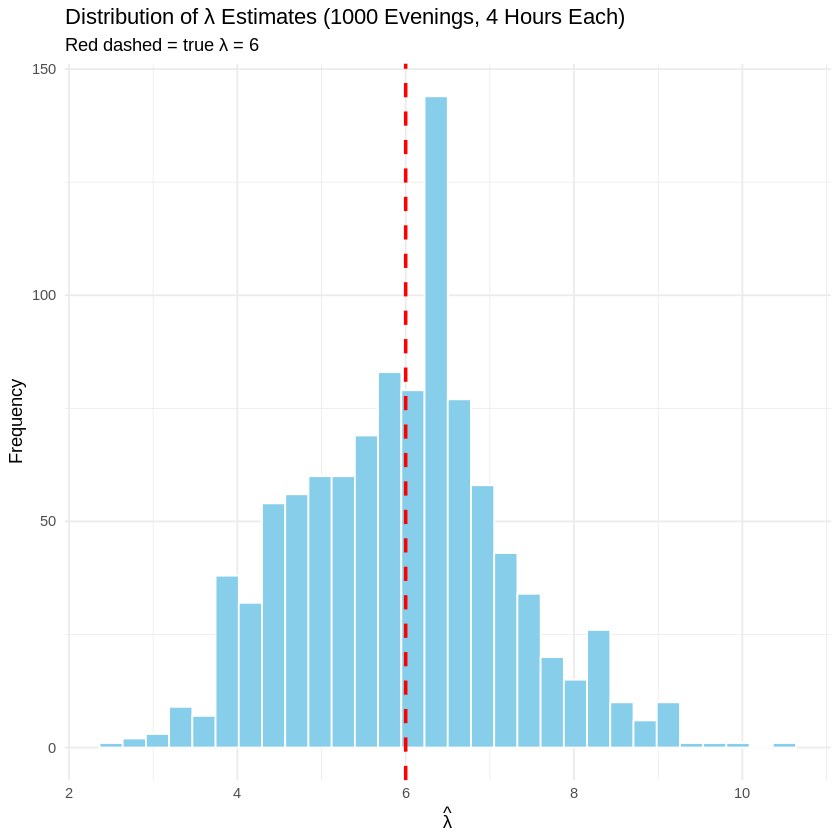

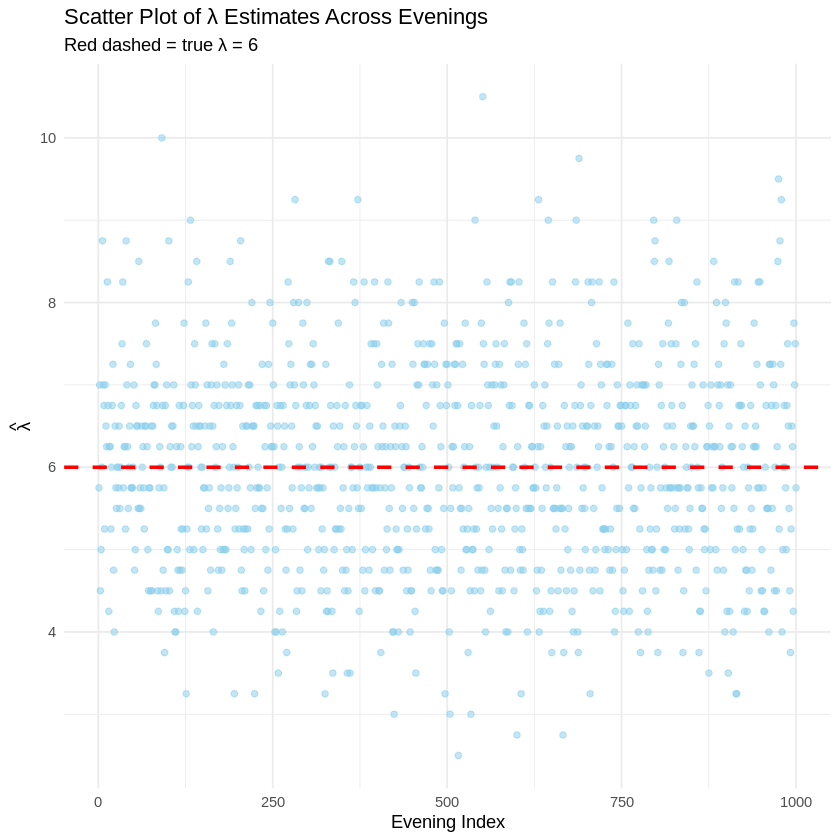

In [9]:
# TODO:
# Simulate 1000 different evenings (4 hours each). For each evening, estimate λ from the 4 hourly counts.
# Then visualize how much the estimate changes from evening to evening (histogram + scatter plot),
# and report the average and standard deviation of these 1000 estimates. Mark the true λ on the plots.
set.seed(7)

lambda_true <- 6
B <- 1000
hours_per_evening <- 4

# Simulate 1000 evenings, each with 4 hourly counts
lambda_estimates <- replicate(B, mean(rpois(hours_per_evening, lambda = lambda_true)))

# Report average and standard deviation of estimates
avg_est <- mean(lambda_estimates)
sd_est  <- sd(lambda_estimates)

cat("Average of 1000 estimates:", avg_est, "\n")
cat("Standard deviation of estimates:", sd_est, "\n")

# Histogram of estimates
library(ggplot2)

df_est <- data.frame(
  evening = 1:B,
  lambda_hat = lambda_estimates
)

# Histogram
p1 <- ggplot(df_est, aes(x = lambda_hat)) +
  geom_histogram(bins = 30, fill = "skyblue", color = "white") +
  geom_vline(xintercept = lambda_true, color = "red", linetype = "dashed", size = 1) +
  labs(
    title = "Distribution of λ Estimates (1000 Evenings, 4 Hours Each)",
    subtitle = paste0("Red dashed = true λ = ", lambda_true),
    x = expression(hat(lambda)),
    y = "Frequency"
  ) +
  theme_minimal()

# Scatter plot of estimates across evenings
p2 <- ggplot(df_est, aes(x = evening, y = lambda_hat)) +
  geom_point(alpha = 0.5, color = "skyblue") +
  geom_hline(yintercept = lambda_true, color = "red", linetype = "dashed", size = 1) +
  labs(
    title = "Scatter Plot of λ Estimates Across Evenings",
    subtitle = paste0("Red dashed = true λ = ", lambda_true),
    x = "Evening Index",
    y = expression(hat(lambda))
  ) +
  theme_minimal()

# Display plots
p1
p2


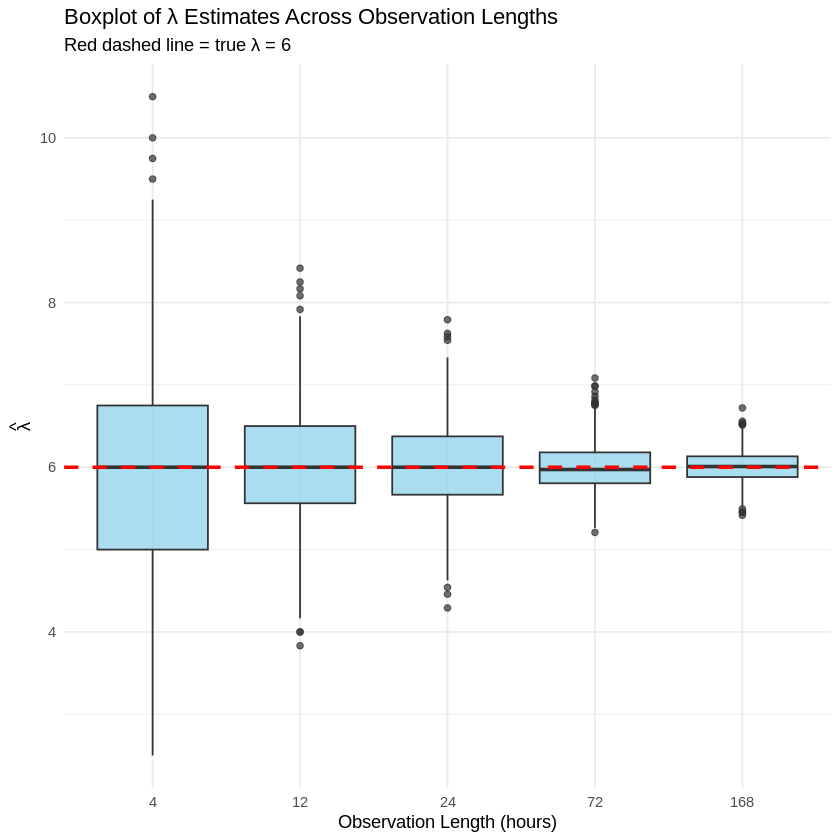

In [10]:
# TODO:
# Compare the λ estimates across different observation lengths by plotting them side-by-side.
# Use a boxplot (one box per observation length) to see how the spread shrinks as you observe more hours.
# Add a horizontal reference line for the true λ and write one sentence describing what changes as length increases.
set.seed(7)

lambda_true <- 6
B <- 1000

# Observation lengths (hours)
obs_lengths <- c(4, 12, 24, 72, 168)  # 4 hours, half day, full day, 3 days, 1 week

# Simulate estimates for each observation length
estimates <- lapply(obs_lengths, function(n_hours) {
  replicate(B, mean(rpois(n_hours, lambda = lambda_true)))
})

# Put into tidy data frame
df_box <- data.frame(
  lambda_hat = unlist(estimates),
  hours = factor(rep(obs_lengths, each = B))
)

# Boxplot comparison
library(ggplot2)

ggplot(df_box, aes(x = hours, y = lambda_hat)) +
  geom_boxplot(fill = "skyblue", alpha = 0.7) +
  geom_hline(yintercept = lambda_true, color = "red", linetype = "dashed", size = 1) +
  labs(
    title = "Boxplot of λ Estimates Across Observation Lengths",
    subtitle = paste0("Red dashed line = true λ = ", lambda_true),
    x = "Observation Length (hours)",
    y = expression(hat(lambda))
  ) +
  theme_minimal()


  hours   variance        sd
1     4 1.54788732 1.2441412
2    12 0.48050840 0.6931871
3    24 0.26393210 0.5137432
4    72 0.08450928 0.2907048
5   168 0.03559795 0.1886742


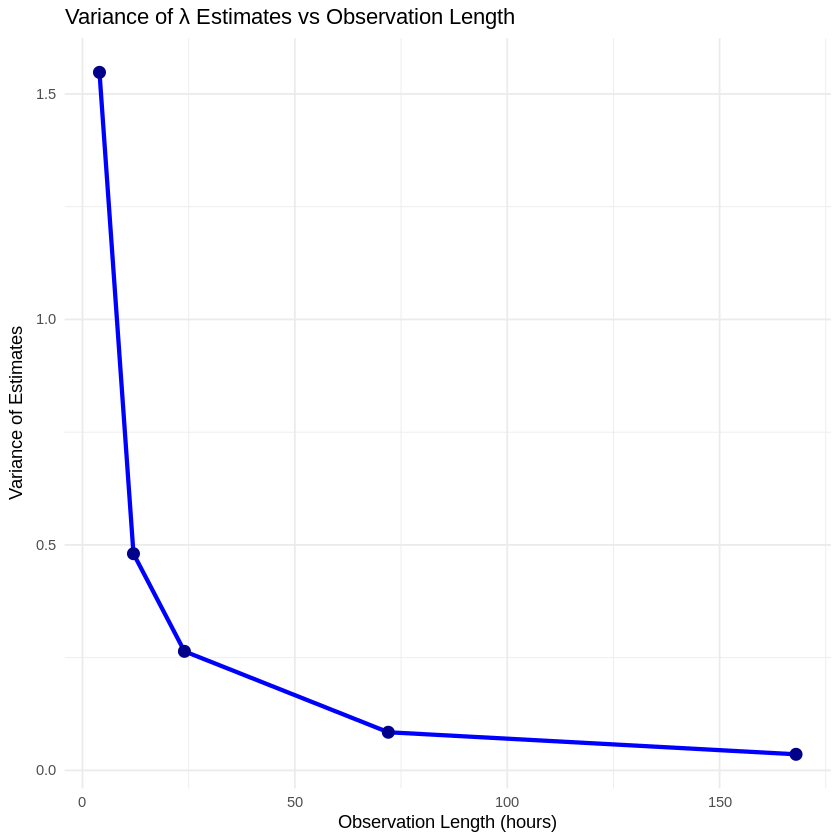

In [11]:
# TODO:
# For each observation length, compute how variable the λ estimates are (variance or SD across the 1000 repeats).
# Plot the variance versus the number of observed hours, and describe the trend in one clear sentence.
set.seed(7)

lambda_true <- 6
B <- 1000
obs_lengths <- c(4, 12, 24, 72, 168)  # 4 hours, half day, full day, 3 days, 1 week

# Simulate estimates for each observation length
estimates <- lapply(obs_lengths, function(n_hours) {
  replicate(B, mean(rpois(n_hours, lambda = lambda_true)))
})

# Compute variance (or SD) of estimates for each length
variability <- sapply(estimates, var)   # variance
sd_values   <- sapply(estimates, sd)    # standard deviation

# Put into tidy data frame
df_var <- data.frame(
  hours = obs_lengths,
  variance = variability,
  sd = sd_values
)

print(df_var)

# Plot variance vs observation length
library(ggplot2)

ggplot(df_var, aes(x = hours, y = variance)) +
  geom_line(color = "blue", size = 1.2) +
  geom_point(color = "darkblue", size = 3) +
  labs(
    title = "Variance of λ Estimates vs Observation Length",
    x = "Observation Length (hours)",
    y = "Variance of Estimates"
  ) +
  theme_minimal()


### Section 5: True vs Estimated distribution

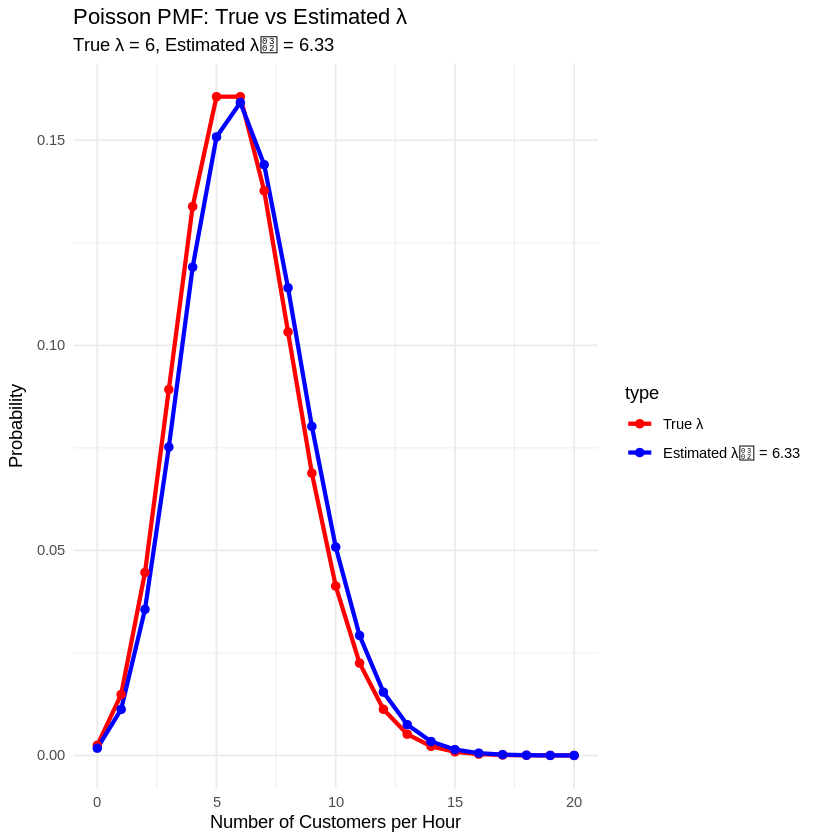

In [24]:
# TODO:
# Use the ML estimate of λ (λ̂ = the sample mean) and plot the Poisson PMF for:
# (1) the true λ and (2) the estimated λ̂ (MLE) on the same figure.

# True lambda
lambda_true <- 6

# ML estimate (from observed sample)
lambda_hat <- mean(x_obs)

# Range of possible counts to plot
x_vals <- 0:20

# Compute PMFs
pmf_true <- dpois(x_vals, lambda = lambda_true)
pmf_hat  <- dpois(x_vals, lambda = lambda_hat)

# Explicit labels (must be identical everywhere)
label_true <- "True λ"
label_hat  <- paste0("Estimated λ̂ = ", round(lambda_hat, 2))

# Build tidy data frame with matching factor levels
df_pmf <- data.frame(
  x = rep(x_vals, 2),
  probability = c(pmf_true, pmf_hat),
  type = factor(rep(c(label_true, label_hat), each = length(x_vals)),
                levels = c(label_true, label_hat))
)

# Plot both PMFs
library(ggplot2)

ggplot(df_pmf, aes(x = x, y = probability, color = type)) +
  geom_line(size = 1.2) +
  geom_point(size = 2) +
  labs(
    title = "Poisson PMF: True vs Estimated λ",
    subtitle = paste0("True λ = ", lambda_true,
                      ", Estimated λ̂ = ", round(lambda_hat, 2)),
    x = "Number of Customers per Hour",
    y = "Probability"
  ) +
  theme_minimal() +
  scale_color_manual(values = setNames(c("red", "blue"), c(label_true, label_hat)))